# Alterações

- RNN espera uma entrada no formato (batch, timesteps, features): (1, 6, 2).

- No controle, o "timestep" para a predição imediata costuma ser o estado atual e a ação de controle.

- Necessidade de normalização antes do $predict$ e desnormalizar após.

- Se o tempo de cálculo explodir, tente converter o modelo para ONNX ou usar apenas as matrizes de pesos da rede para cálculo direto com NumPy. 

In [22]:
import numpy as np

# Normalização

meanX = np.array([11.54549372, 12.4514907 ])
stdX = np.array([4.23449211, 3.9104502 ])
meanY = np.array([ 3.07519347, 46.57397573])
stdY = np.array([2.11485258, 3.02168235])

def std(x):
    return (x - meanX) / stdX

def destd(y_norm):
    return (y_norm * stdY) + meanY

In [23]:
import numpy as np

def rnn_predict(dataset, model_rnn):
    # Formato (6, 2) -> transforma em (1, 6, 2)
    input_data = dataset.reshape(1, 6, 2)
    
    # Normalização

    input_data = std(input_data)

    x_next = model_rnn.predict(input_data, verbose=0)
    
    x_next = destd(x_next)
    #print(x_next.shape)
    return x_next.flatten()

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model

# --------------------------------------------------------------------------
# Modelos RNN
# --------------------------------------------------------------------------
model_rnn = load_model('./model_JacketedTank.h5', compile = False)
#model_rnn.summary() 
# --------------------------------------------------------------------------
# Modelos Fenomenológico
# --------------------------------------------------------------------------
def jacketed_tank(x, t, u, m):
    L, T = x
    #Fin, Q = u
    Fi, Fv = u

    # Importando parâmetros
    At  = m['At']
    k   = m['k']
    rho = m['rho']
    Cp  = m['Cp']
    lmb = m['lambda']
    Ti  = m['Ti']

    # Modelo simplificado: Fout = k * sqrt(h)
    f1 = (Fi - k * np.sqrt(L) / At)
    f2 = (rho * Fi * Cp * (Ti - T) + Fv * lmb) / (rho * At * L * Cp)
    f = [f1 , f2]
    
    return f

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 6, 64)          │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,458 (29.13 KB)

 Trainable params: 7,458 (29.13 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
import numpy as np

# --------------------------------------------------------------------------
# Função Objetivo do NMPC
# --------------------------------------------------------------------------
def fob_NMPC(du, uk_1, Hp, Hc, ysp, q, r, memory_buffer, x0, nu, modelo_rnn):
    du = du.reshape((Hc, nu))
    J = 0

    dataset = memory_buffer.copy()
    u_atual = uk_1.copy()

    x_sim = dataset[-1, :].copy() # Último estado conhecido
    bias = x0 - x_sim    

    for i in range(Hp):
        if i < Hc:
            u_atual = u_atual + du[i, :]

        # 1 Predição baseada na JANELA atual
        x_pred = rnn_predict(dataset, model_rnn)

        # 2 Atualiza a janela para o próximo passo da predição (Shift)
        # Remove o primeiro, adiciona o predito no fim
        dataset = np.roll(dataset, -1, axis=0)
        dataset[-1, :] = x_pred
        
        # 3 Cálculo do custo
        y_hat = x_pred + bias
        error = y_hat - ysp
        J += np.dot(error, np.dot(np.diag(q), error))
        
        if i < Hc:
            J += np.dot(du[i, :], np.dot(np.diag(r), du[i, :]))
            
    return J

In [26]:
import numpy as np

# --------------------------------------------------------------------------
# Parâmetros e Configurações
# --------------------------------------------------------------------------
modelo = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}
nsim = 50
Hp, Hc = 10, 2
q = np.array([10, 10])
r = np.array([0.1, 0.1])
Ts = 0.1
nu, ny = 2, 2

# Restrições
umin = np.array([5, 5])
umax = np.array([20, 30])
dumax = np.array([1, 2])

# Condições iniciais
uk_1 = np.array([10.0, 10.0])
x0 = np.array([2.0408, 45.4])
x0m = x0.copy()
du0 = np.zeros(Hc * nu)

# Armazenamento de dados
history = {'yp': [], 'uk': [], 'sp': [], 'J': [], 'tcalc': []}

Toda vez que a planta da um valor novo o buffer é atualizado;

In [27]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import odeint
import time
    
# --------------------------------------------------------------------------
# Loop de Simulação
# --------------------------------------------------------------------------
# Ajuste de Entrada da RNN
memory_buffer = np.tile(uk_1, (6, 1))

for k in range(nsim):
    if(k<50):
        ysp = np.array([3.0, 50.0])
    if(50 < k < 100):
        ysp = np.array([2.5, 47.0])
    if(k>100):
        ysp = np.array([4.0, 48.0])

    #memory_buffer = np.roll(memory_buffer, -1, axis=0)
    #memory_buffer[-1, :] = ysp # Adiciona a medição real ao histórico
    
    # Restrições para o otimizador (Bounds para Delta U e U total)
    # Aqui simplificamos usando os limites de variação (dumax)
    bounds = [(-dumax[i%nu], dumax[i%nu]) for i in range(Hc*nu)]
    
    start_time = time.time() # 1 Marca o tempo de início
  
    res = minimize(fob_NMPC,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, memory_buffer, x0m, nu, model_rnn),
                   method='SLSQP', 
                   bounds=bounds)
    '''
    
    res = minimize(fob_NMPC,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, x0m, nu, modelo),
                   method='SLSQP', 
                   bounds=bounds)
    '''
    history['tcalc'].append(time.time() - start_time) # 2 Calcula a diferença
    
    du_opt = res.x.reshape((Hc, nu))
    uk_atual = uk_1 + du_opt[0, :]
    
    # Saturação manual dos limites de U
    uk_atual = np.clip(uk_atual, umin, umax)
    
    memory_buffer = np.roll(memory_buffer, -1, axis=0)
    memory_buffer[-1, :] = uk_atual # Adiciona a medição real ao histórico

    # Planta (Simulação real)
    mult = 1 if k < 80 else 1.1
    u_planta = uk_atual * mult
    x_next_p = odeint(jacketed_tank, x0, [0, Ts], args=(u_planta, modelo))[-1, :]

    # Modelo (Simulação interna do controlador)
    x_next_m = rnn_predict(memory_buffer, model_rnn)

    # Atualização
    history['yp'].append(x_next_p)
    history['uk'].append(uk_atual)
    history['sp'].append(ysp)
    history['J'].append(res.fun)
    
    x0, x0m, uk_1 = x_next_p, x_next_m, uk_atual
    du0 = np.concatenate([du_opt[1:], np.zeros((1, nu))]).flatten()
print(memory_buffer)

[[10. 10.]
 [10. 10.]
 [10. 10.]
 [10. 10.]
 [10. 10.]
 [10. 10.]]


Tempo Máximo[s] =  6.408854007720947 
Tempo Médio[s] =  5.372044858932495 
Tempo Total[s] =  268.60224294662476


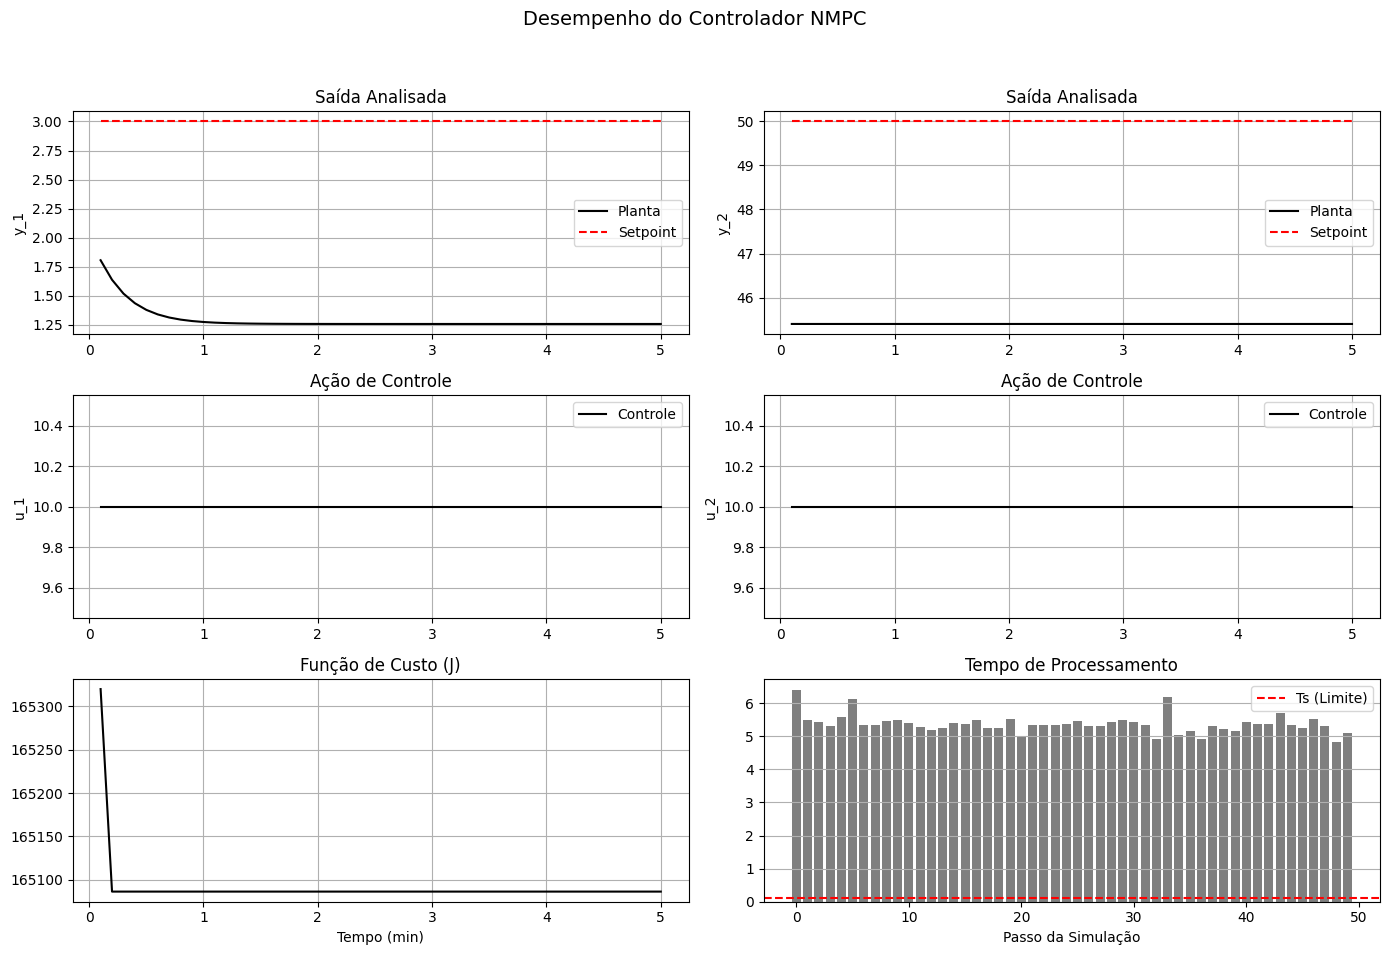

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Gráficos
# --------------------------------------------------------------------------
history['yp'] = np.array(history['yp'])
history['uk'] = np.array(history['uk'])
history['sp'] = np.array(history['sp'])
history['cost'] = np.array(history['J'])
t_axis = np.linspace(Ts, nsim*Ts, nsim)

tempo_medio = np.mean(history['tcalc'])
tempo_max = np.max(history['tcalc'])
tempo_sum = np.sum(history['tcalc'])
print(f'Tempo Máximo[s] = ', tempo_max, '\nTempo Médio[s] = ', tempo_medio, '\nTempo Total[s] = ', tempo_sum)

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Desempenho do Controlador NMPC', fontsize=14)

# --- 1. SAÍDAS (y) ---
for i in range(ny):
    axs[0, i].plot(t_axis, history['yp'][:, i], 'k', label='Planta')
    axs[0, i].plot(t_axis, history['sp'][:, i], 'r--', label='Setpoint')
    axs[0, i].set_title(f'Saída Analisada')
    axs[0, i].set_ylabel(f'y_{i+1}')
    axs[0, i].grid(True)
    axs[0, i].legend()

# --- 2. ENTRADAS (u) ---
for i in range(nu):
    axs[1, i].step(t_axis, history['uk'][:, i], 'k', label='Controle', where='post')
    axs[1, i].set_title(f'Ação de Controle')
    axs[1, i].set_ylabel(f'u_{i+1}')
    axs[1, i].grid(True)
    axs[1, i].legend()

# --- 3. DESEMPENHO (Custo e Tempo) ---
# Gráfico de Custo
axs[2, 0].plot(t_axis, history['J'], 'k', label= 'Custo', linewidth=1.5)
axs[2, 0].set_title('Função de Custo (J)')
axs[2, 0].set_xlabel('Tempo (min)')
axs[2, 0].grid(True)

# Gráfico de Tempo de Cálculo
axs[2, 1].bar(range(nsim), history['tcalc'], color='k', alpha=0.5)
axs[2, 1].axhline(y=Ts, color='r', linestyle='--', label='Ts (Limite)')
axs[2, 1].set_title('Tempo de Processamento')
axs[2, 1].set_xlabel('Passo da Simulação')
axs[2, 1].legend()
axs[2, 1].grid(axis='y')

# Ajuste fino para não sobrepor títulos e eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()